# Final Project: Source Extraction with SEP

This notebook follows the SEP tutorial and applies it to the file
`hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits`.

Goals:
1. Find how many sources are in the image and histogram their fluxes.
2. Compute the mean, median, and standard deviation of the flux distribution.
3. Identify the largest outlier and how many standard deviations it is from the mean.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import sep

from astropy.io import fits
from matplotlib import rcParams

rcParams["figure.figsize"] = (10, 8)

In [18]:
filename = "hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits"

# Inspect the file first
fits.info(filename)

Filename: hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (3600, 3600)   float32   


In [19]:
data = fits.getdata(filename, ext=0)

data = data.astype(data.dtype.newbyteorder("="))

print(data.shape)
print(data.dtype)

(3600, 3600)
float32


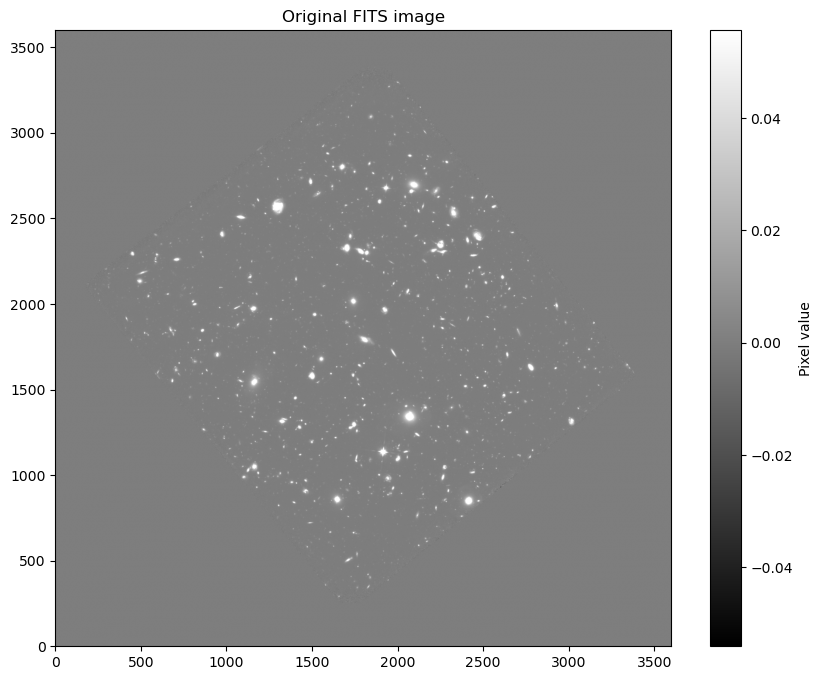

In [20]:
m, s = np.mean(data), np.std(data)

plt.imshow(data, cmap="gray", origin="lower", vmin=m-s, vmax=m+s)
plt.colorbar(label="Pixel value")
plt.title("Original FITS image")
plt.show()

## Background estimation and subtraction
SEP recommends estimating the background before source detection.

In [21]:
bkg = sep.Background(data)

print("Global background:", bkg.globalback)
print("Global RMS:", bkg.globalrms)

Global background: 0.0
Global RMS: 0.0005398219218477607


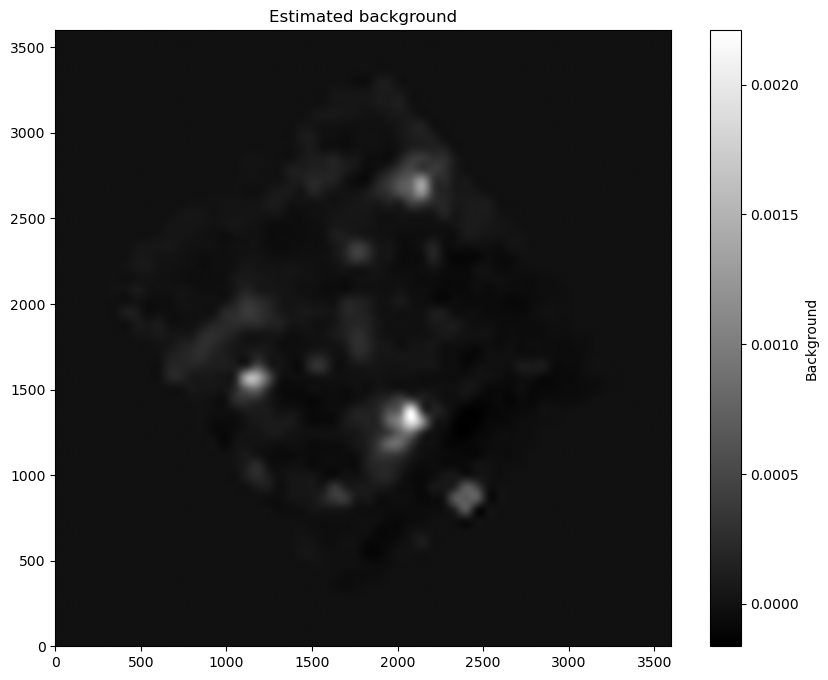

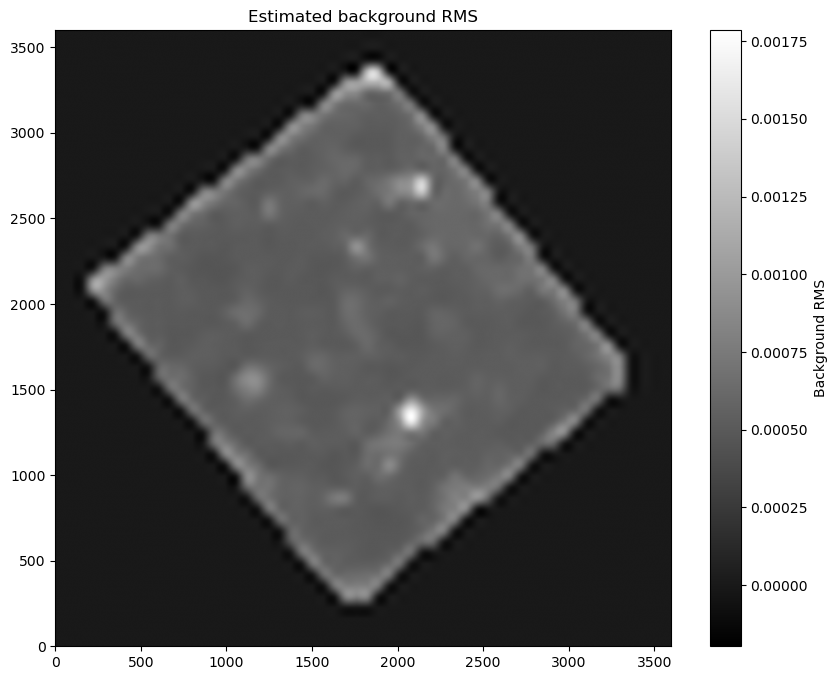

In [22]:
bkg_image = bkg.back()
bkg_rms = bkg.rms()

plt.imshow(bkg_image, cmap="gray", origin="lower")
plt.colorbar(label="Background")
plt.title("Estimated background")
plt.show()

plt.imshow(bkg_rms, cmap="gray", origin="lower")
plt.colorbar(label="Background RMS")
plt.title("Estimated background RMS")
plt.show()

In [23]:
data_sub = data - bkg

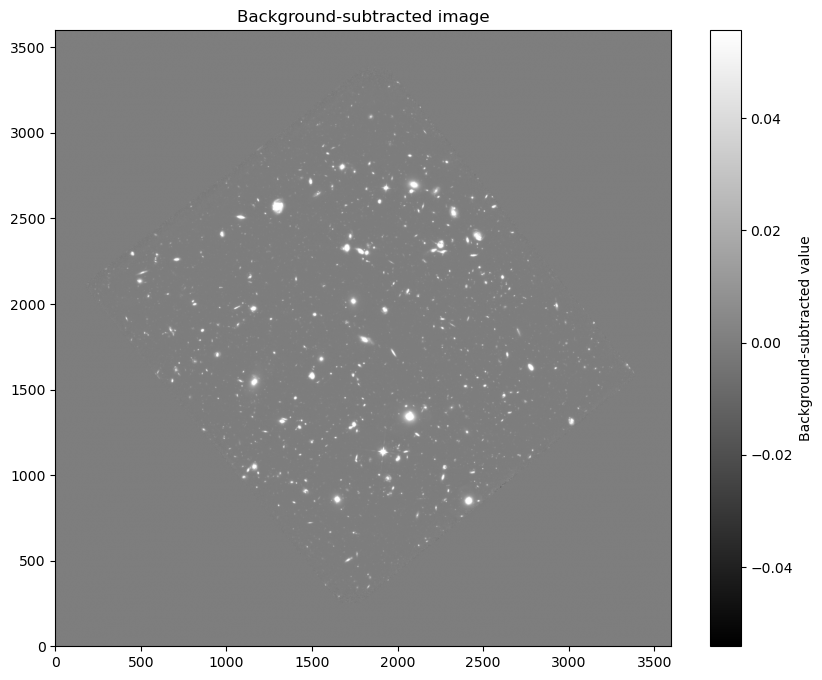

In [24]:
m, s = np.mean(data_sub), np.std(data_sub)

plt.imshow(data_sub, cmap="gray", origin="lower", vmin=m-s, vmax=m+s)
plt.colorbar(label="Background-subtracted value")
plt.title("Background-subtracted image")
plt.show()

## Source detection
Using SEP to detect sources in the background-subtracted image.

In [25]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

print("Number of detected sources:", len(objects))
print(objects.dtype.names)

Number of detected sources: 8641
('thresh', 'npix', 'tnpix', 'xmin', 'xmax', 'ymin', 'ymax', 'x', 'y', 'x2', 'y2', 'xy', 'errx2', 'erry2', 'errxy', 'a', 'b', 'theta', 'cxx', 'cyy', 'cxy', 'cflux', 'flux', 'cpeak', 'peak', 'xcpeak', 'ycpeak', 'xpeak', 'ypeak', 'flag')


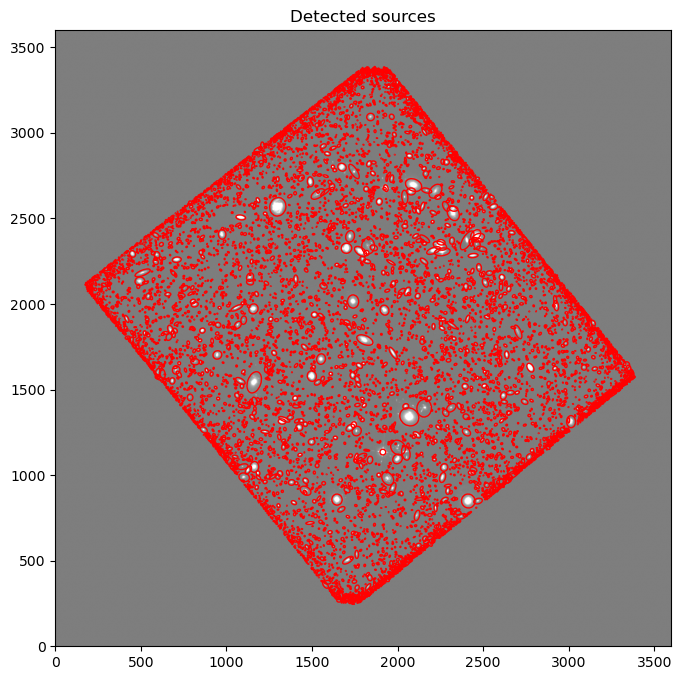

In [26]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)

ax.imshow(data_sub, cmap="gray", origin="lower", vmin=m-s, vmax=m+s)

for i in range(len(objects)):
    e = Ellipse(
        xy=(objects["x"][i], objects["y"][i]),
        width=6 * objects["a"][i],
        height=6 * objects["b"][i],
        angle=objects["theta"][i] * 180.0 / np.pi
    )
    e.set_facecolor("none")
    e.set_edgecolor("red")
    ax.add_artist(e)

ax.set_title("Detected sources")
plt.show()

## Aperture photometry
Measure fluxes for the detected sources.

In [27]:
flux, fluxerr, flag = sep.sum_circle(
    data_sub,
    objects["x"],
    objects["y"],
    3.0,
    err=bkg.globalrms,
    gain=1.0
)

print("First 10 fluxes:")
for i in range(min(10, len(flux))):
    print(f"object {i}: flux = {flux[i]:.3f} +/- {fluxerr[i]:.3f}")

First 10 fluxes:
object 0: flux = 0.031 +/- 0.177
object 1: flux = 0.031 +/- 0.176
object 2: flux = -0.024 +/- 0.003
object 3: flux = 0.002 +/- 0.044
object 4: flux = 0.012 +/- 0.112
object 5: flux = -0.011 +/- 0.003
object 6: flux = 0.029 +/- 0.171
object 7: flux = -0.009 +/- 0.003
object 8: flux = 0.048 +/- 0.219
object 9: flux = 0.028 +/- 0.167


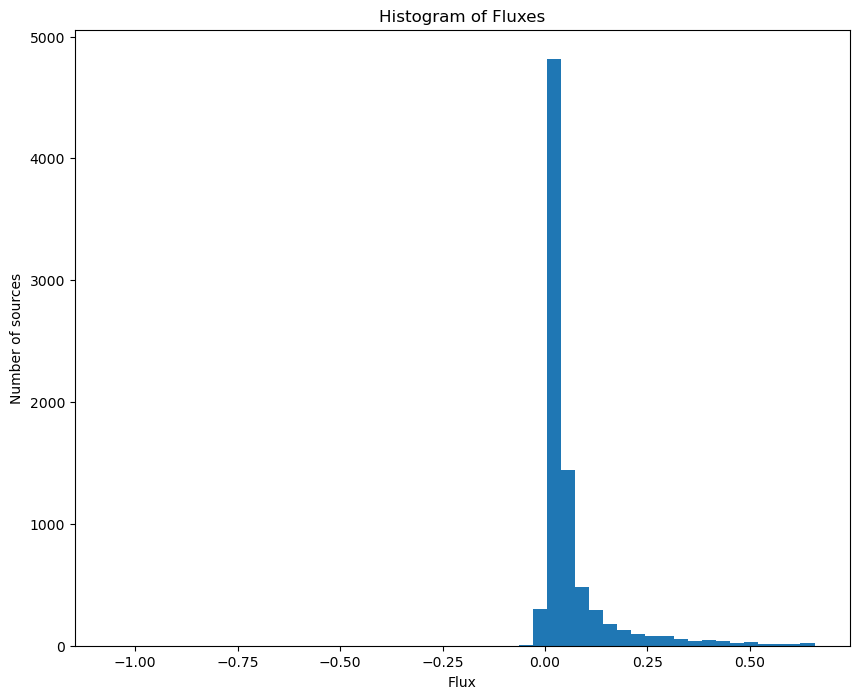

In [43]:
plt.hist(flux, bins=50, range=(min(flux), np.percentile(flux, 95)))
plt.xlabel("Flux")
plt.ylabel("Number of sources")
plt.title("Histogram of Fluxes")
plt.show()

In [41]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation of flux:", std_flux)

Mean flux: 0.36181040728805286
Median flux: 0.030961835534690188
Standard deviation of flux: 9.242994159843427


In [29]:
deviations = np.abs(flux - mean_flux)
imax = np.argmax(deviations)

largest_outlier = flux[imax]
sigma_away = deviations[imax] / std_flux

print("Largest outlier flux:", largest_outlier)
print("Index of largest outlier:", imax)
print("Standard deviations from mean:", sigma_away)

Largest outlier flux: 807.2972835731507
Index of largest outlier: 2065
Standard deviations from mean: 87.30238916212102


## Final Answers

1. Number of detected sources:8641

2. Flux distribution statistics:
   - Mean =0.36181040728805286
   - Median =0.030961835534690188
   - Standard deviation = 9.242994159843427

3. Largest outlier:
   - Flux =807.2972835731507
   - Distance from mean =87.30238916212102  standard deviations